In the name of God

# Q2: Image Caption Generation|

In this notebook we will build and train a Neural Network model for generating captions for images using CNN, RNN and Attention mechanisms, following the work done in this paper (https://arxiv.org/abs/1502.03044)

## 2-1. Data preparation

To begin we will download the data, perform some preprocessing on both the images and the captions, create the vocabulary and visualise a few of the images along with their captions.

### 2-1-1. Downloading the data

We will use a translated version of the COCO Captions dataset which consists of 40,000 image-caption pairs.

### 2-1-2. Image preprocessing

Now in order to prepare the dataset to later be used in our model we will resize all the images to a fixed dimension and normalise the pixel values to the range [0, 1] with a min-max scalar (which is automatically done by ToTensor() function in our transformation).

We will also create a custom ImageCaptionDataset class that eharites from the Dataset class of pytorch to load and pair the image-caption pairs for our model.

Finally to verify the process of loading and resizing, we will display one of the images in the dataset.

torch.Size([3, 224, 224])
یک تکه ماهی و کلم بروکلی و هویج که بخار پز شده به نظر می رسد


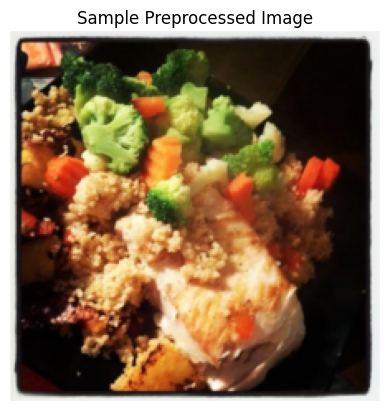

In [1]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import matplotlib.pyplot as plt

image_size = 224
image_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)), 
    transforms.ToTensor()
])


class ImageCaptionDataset(Dataset):
    def __init__(self, captions_file_path, image_directory, transform):
        self.annotations = pd.read_csv(captions_file_path)
        self.image_directory = image_directory
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        image_name = os.path.join(self.image_directory, self.annotations.iloc[idx, 0])
        image = Image.open(image_name).convert("RGB")
        caption = self.annotations.iloc[idx, 1]

        image = self.transform(image)

        return image, caption

captions_file_path = 'dataset/data.csv'
images_folder = 'dataset/images'

coco_dataset = ImageCaptionDataset(
    captions_file_path=captions_file_path,
    image_directory=images_folder,
    transform=image_transforms
)

image, caption = coco_dataset[24]

print(image.shape)
print(caption)

plt.imshow(image.permute(1, 2, 0))
plt.title("Sample Preprocessed Image")
plt.axis('off')
plt.show()

### 2-1-2. Caption preprocessing

For this section we will use the hazm library to normalise Persian texts and remove punctuations and special characters and numbers.

In [3]:
import pandas as pd
import re
from hazm import Normalizer
from torch.utils.data import Dataset
from PIL import Image
import os

normalizer = Normalizer()
def preprocess_caption(text):
    normalized_text = normalizer.normalize(text)
    cleaned_text = re.sub(r'[^ابپتثجچحخدذرزژسشصضطظعغفقکگلمنوهیآ ]+', '', normalized_text)
    cleaned_text = re.sub(r'[0-9]+', '', cleaned_text)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
    return cleaned_text

captions_file_path = 'dataset/data.csv'
df = pd.read_csv(captions_file_path)
df['cleaned_caption'] = df['text'].apply(preprocess_caption)

class ImageCaptionDataset(Dataset):
    def __init__(self, dataframe, image_directory, transform):
        self.annotations = dataframe
        self.image_directory = image_directory
        self.transform = transform
        self.img_col = self.annotations.columns[0]
        self.caption_col = 'cleaned_caption'


    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        image_name = os.path.join(self.image_directory, self.annotations[self.img_col].iloc[idx])
        image = Image.open(image_name).convert("RGB")
        caption = self.annotations[self.caption_col].iloc[idx]

        if self.transform:
            image = self.transform(image)

        return image, caption

coco_dataset = ImageCaptionDataset(
    dataframe=df,
    image_directory=images_folder,
    transform=image_transforms
)

image, caption = coco_dataset[24]
print("Cleaned Caption:", caption)

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject